In [53]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [54]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B")


In [55]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [59]:
model.lm_head.weight.data

tensor([[ 0.0045,  0.0166,  0.0210,  ..., -0.0054, -0.0422, -0.0315],
        [ 0.0215, -0.0238,  0.0211,  ..., -0.0107, -0.0011, -0.0374],
        [ 0.0136,  0.0104,  0.0128,  ...,  0.0081, -0.0122,  0.0051],
        ...,
        [ 0.0009,  0.0164, -0.0193,  ..., -0.0003, -0.0030,  0.0066],
        [ 0.0009,  0.0164, -0.0193,  ..., -0.0003, -0.0030,  0.0066],
        [ 0.0009,  0.0164, -0.0193,  ..., -0.0003, -0.0030,  0.0066]])

In [22]:
text = "What is the capital of France?"
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs, output_hidden_states=True)

In [24]:
outputs.keys()

odict_keys(['logits', 'past_key_values', 'hidden_states'])

In [28]:
print(len(outputs.hidden_states))
print(outputs.hidden_states[-1].shape)

17
torch.Size([1, 8, 2048])


In [31]:
model.lm_head

Linear(in_features=2048, out_features=128256, bias=False)

In [34]:
out = model.lm_head(outputs.hidden_states[-1])

In [35]:
out

tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7597],
         [11.6842,  8.4083,  7.3702,  ..., -0.2775, -0.2776, -0.2776],
         [ 8.2787,  9.0717,  6.5711,  ..., -0.1754, -0.1750, -0.1752],
         ...,
         [ 6.0271,  6.9366,  3.8610,  ...,  0.1696,  0.1700,  0.1699],
         [ 4.9756,  5.3153,  7.7481,  ..., -0.7064, -0.7068, -0.7072],
         [ 5.5582,  0.6414,  4.9882,  ..., -2.2305, -2.2305, -2.2308]]],
       grad_fn=<UnsafeViewBackward0>)

In [37]:
outputs.logits

tensor([[[ 7.0544,  9.0268, 13.3233,  ..., -3.7595, -3.7596, -3.7597],
         [11.6842,  8.4083,  7.3702,  ..., -0.2775, -0.2776, -0.2776],
         [ 8.2787,  9.0717,  6.5711,  ..., -0.1754, -0.1750, -0.1752],
         ...,
         [ 6.0271,  6.9366,  3.8610,  ...,  0.1696,  0.1700,  0.1699],
         [ 4.9756,  5.3153,  7.7481,  ..., -0.7064, -0.7068, -0.7072],
         [ 5.5582,  0.6414,  4.9882,  ..., -2.2305, -2.2305, -2.2308]]],
       grad_fn=<UnsafeViewBackward0>)

In [38]:
head_weights = model.lm_head.weight
head_weights.shape

torch.Size([128256, 2048])

In [40]:
model_weight_normalized = head_weights / head_weights.norm(dim=1, keepdim=True)
print(model_weight_normalized.shape)

torch.Size([128256, 2048])


In [42]:
print(model_weight_normalized.norm(dim=1).shape)

torch.Size([128256])


In [43]:
last_output = outputs.hidden_states[-1]
last_output_normalized = last_output / last_output.norm(dim=-1, keepdim=True)

In [45]:
last_output_normalized.shape

torch.Size([1, 8, 2048])

In [46]:
cosine_sim = last_output_normalized @ model_weight_normalized.T

In [50]:
cosine_sim = cosine_sim.squeeze()
print(cosine_sim.shape)

torch.Size([8, 128256])


In [52]:
print(cosine_sim.argmax(dim=-1))
print(cosine_sim.max(dim=-1))

tensor([14924,   374,   279,   836,   315, 17368,  5380,   627])
torch.return_types.max(
values=tensor([0.2270, 0.2630, 0.2481, 0.1911, 0.3272, 0.2609, 0.3285, 0.1918],
       grad_fn=<MaxBackward0>),
indices=tensor([14924,   374,   279,   836,   315, 17368,  5380,   627]))


### Dataset stuff

In [26]:
from datasets import load_dataset, load_from_disk
from pathlib import Path
from transformers import AutoTokenizer
import os


save_name = Path("wikitext")

if save_name.exists():
    print(f"Dataset already exists at {save_name}, loading from disk...")
    ds = load_from_disk(str(save_name))
else:
    print(f"Downloading dataset and saving to {save_name}...")
    ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
    ds.save_to_disk(str(save_name))

Dataset already exists at wikitext, loading from disk...


In [27]:
ds

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [28]:
all_combined = [ds['train'][i]['text'] for i in range(len(ds['train']))]

In [29]:
print(all_combined[:1000])

['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgi

In [30]:
all_combined = " ".join(all_combined[:3000])

In [31]:
print(len(all_combined))

904603


In [32]:
from transformers import AutoTokenizer
model_name = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [33]:
all_combined_text_tokenized = tokenizer(all_combined, return_tensors="pt").input_ids

Token indices sequence length is longer than the specified maximum sequence length for this model (202975 > 131072). Running this sequence through the model will result in indexing errors


In [34]:
print(all_combined_text_tokenized.shape)

torch.Size([1, 202975])


In [35]:
import torch

def chunk_with_bos(tensor, chunk_size, tokenizer):
    """
    Chunk a tokenized tensor and prepend BOS token to all chunks except the first.
    All chunks will be exactly chunk_size.
    
    Args:
        tensor: torch.Tensor of shape [1, seq_len] - tokenized tensor
        chunk_size: int - size of each chunk (all chunks will be this size)
        tokenizer: transformers tokenizer - to get BOS and PAD token IDs
    
    Returns:
        list of torch.Tensors - chunks with BOS prepended (except first), each of shape [chunk_size]
    """
    # Get token IDs
    bos_token_id = tokenizer.bos_token_id
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    if bos_token_id is None:
        raise ValueError("Tokenizer does not have a BOS token ID")
    
    # Remove batch dimension to get [seq_len]
    tokens = tensor.squeeze(0)  # Shape: [seq_len]
    seq_len = tokens.shape[0]
    
    chunks = []
    i = 0
    
    # First chunk: take exactly chunk_size tokens (already has BOS)
    if seq_len > 0:
        first_chunk = tokens[i:i + chunk_size]
        if len(first_chunk) < chunk_size:
            # Pad if first chunk is shorter (shouldn't happen but handle it)
            padding = torch.full((chunk_size - len(first_chunk),), pad_token_id, dtype=first_chunk.dtype)
            first_chunk = torch.cat([first_chunk, padding])
        chunks.append(first_chunk)
        i += chunk_size
    
    # Subsequent chunks: take (chunk_size - 1) tokens + 1 BOS = chunk_size total
    while i < seq_len:
        # Take chunk_size - 1 tokens from the sequence (since we'll prepend BOS)
        remaining = seq_len - i
        if remaining < chunk_size - 1:
            # Not enough tokens for full chunk, pad it
            chunk_tokens = tokens[i:]
            bos_tensor = torch.tensor([bos_token_id], dtype=tokens.dtype)
            chunk = torch.cat([bos_tensor, chunk_tokens])
            
            # Pad to chunk_size
            padding_needed = chunk_size - len(chunk)
            if padding_needed > 0:
                padding = torch.full((padding_needed,), pad_token_id, dtype=tokens.dtype)
                chunk = torch.cat([chunk, padding])
        else:
            # Normal case: take (chunk_size - 1) tokens + prepend BOS
            chunk_tokens = tokens[i:i + chunk_size - 1]
            bos_tensor = torch.tensor([bos_token_id], dtype=tokens.dtype)
            chunk = torch.cat([bos_tensor, chunk_tokens])
        
        chunks.append(chunk)
        i += chunk_size - 1  # Move forward by (chunk_size - 1) since we consumed that many
    
    return chunks

In [36]:
a = chunk_with_bos(all_combined_text_tokenized, 1000, tokenizer)

In [37]:
len(a)

204

In [39]:
print(a[0].shape)

torch.Size([1000])


In [1]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-3B")

/Users/sungwonkim/Desktop/llm_vector_change_experiment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.72s/it]


In [6]:
a = model.model.embed_tokens.weight

In [8]:
b = model.lm_head.weight

In [9]:
a

Parameter containing:
tensor([[ 0.0110,  0.0111,  0.0132,  ..., -0.0026, -0.0189,  0.0067],
        [ 0.0134,  0.0013,  0.0210,  ...,  0.0007,  0.0327, -0.0026],
        [ 0.0251,  0.0204,  0.0284,  ..., -0.0012, -0.0008, -0.0079],
        ...,
        [-0.0083,  0.0036,  0.0050,  ..., -0.0024, -0.0020, -0.0052],
        [-0.0083,  0.0036,  0.0050,  ..., -0.0024, -0.0020, -0.0052],
        [-0.0083,  0.0036,  0.0050,  ..., -0.0024, -0.0020, -0.0052]],
       requires_grad=True)

In [16]:
print(model.get_input_embeddings())

Embedding(128256, 3072)


In [13]:
import torch

In [14]:
print(torch.allclose(a.detach().cpu(), b.detach().cpu(), atol=1e-5, rtol=1e-4))

True


In [2]:
# view results
import numpy as np
data = np.load("results/wikitext_results_20251031_215803/results.npz")

In [6]:
a = data['cos_values'].squeeze(1)

In [12]:
a = data['logit_values'].squeeze(1)

In [13]:
sim = a[:,:,0]

In [14]:
sim.shape

(204, 1000)

In [15]:
sim

array([[14.8265505, 21.633526 , 15.08942  , ..., 20.163738 , 21.95924  ,
        18.943926 ],
       [14.8265505, 19.724783 , 20.03399  , ..., 21.06355  , 20.400753 ,
        22.441975 ],
       [14.8265505, 16.141823 , 21.057035 , ..., 26.865688 , 22.179161 ,
        19.654432 ],
       ...,
       [14.8265505, 16.408022 , 19.127783 , ..., 25.671558 , 24.809122 ,
        21.630236 ],
       [14.8265505, 14.860001 , 18.327148 , ..., 18.348639 , 21.527529 ,
        25.656544 ],
       [14.8265505, 16.544737 , 17.828102 , ..., 10.480267 , 10.47575  ,
        10.486148 ]], shape=(204, 1000), dtype=float32)

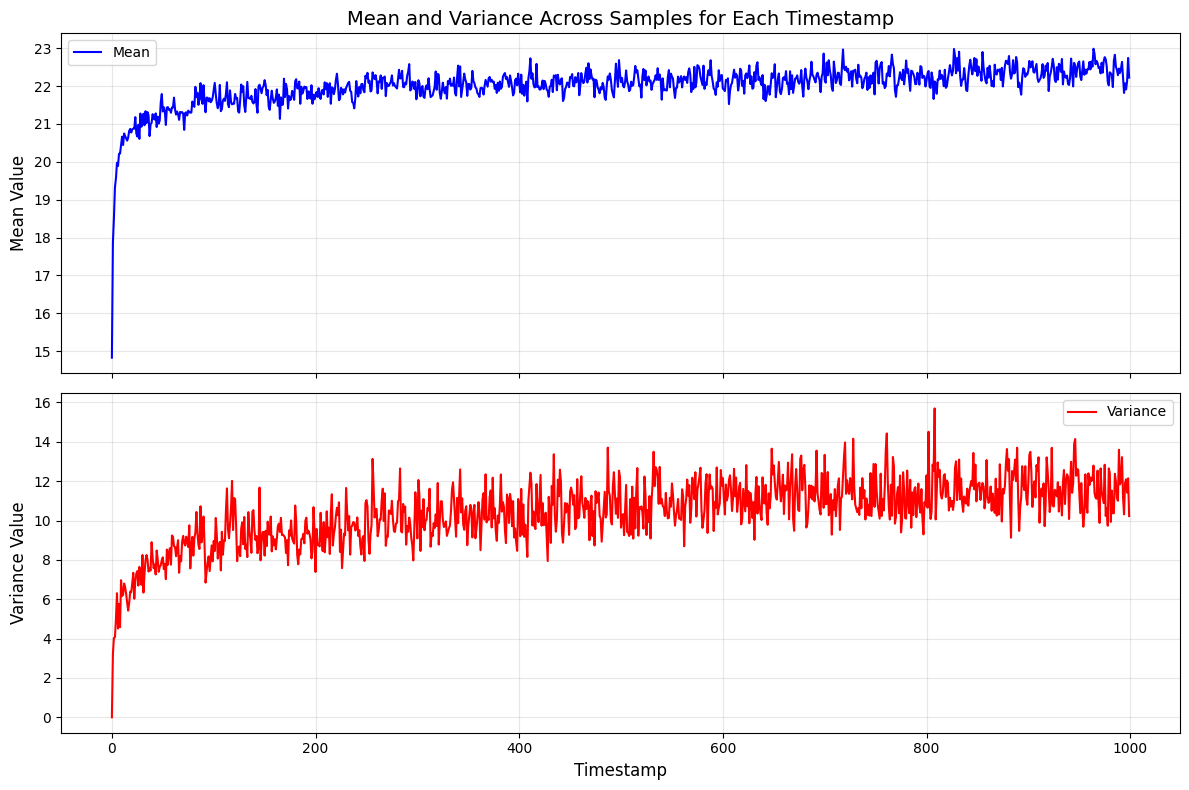

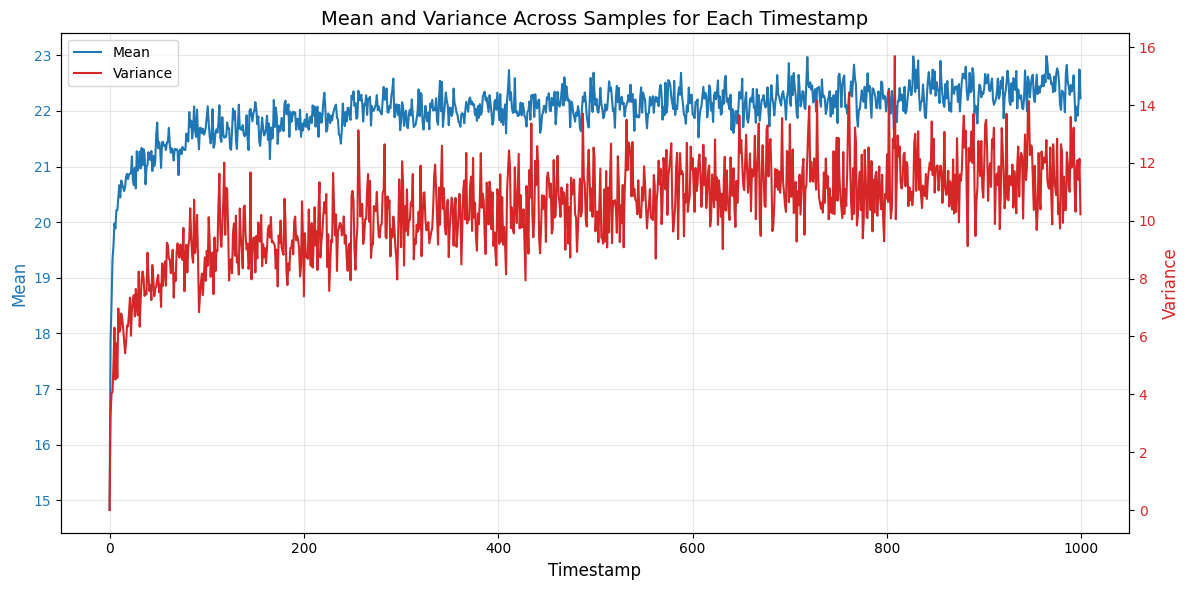

Array shape: (204, 1000)
Mean shape: (1000,)
Variance shape: (1000,)

Mean statistics:
  Min: 14.8266, Max: 22.9870, Avg: 22.0170

Variance statistics:
  Min: 0.0000, Max: 15.6972, Avg: 10.4302


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your array in variable 'sim' with shape (a, b)
# where a = sample number, b = timestamp

# Compute mean across samples (axis=0) for each timestamp
mean_values = np.mean(sim, axis=0)  # Shape: (b,)

# Compute variance across samples (axis=0) for each timestamp
variance_values = np.var(sim, axis=0)  # Shape: (b,)

# Create timestamps (x-axis)
timestamps = np.arange(sim.shape[1])

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot mean
ax1.plot(timestamps, mean_values, 'b-', linewidth=1.5, label='Mean')
ax1.set_ylabel('Mean Value', fontsize=12)
ax1.set_title('Mean and Variance Across Samples for Each Timestamp', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot variance
ax2.plot(timestamps, variance_values, 'r-', linewidth=1.5, label='Variance')
ax2.set_xlabel('Timestamp', fontsize=12)
ax2.set_ylabel('Variance Value', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Alternative: Plot both on the same graph with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Timestamp', fontsize=12)
ax1.set_ylabel('Mean', color=color, fontsize=12)
line1 = ax1.plot(timestamps, mean_values, color=color, linewidth=1.5, label='Mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Variance', color=color, fontsize=12)
line2 = ax2.plot(timestamps, variance_values, color=color, linewidth=1.5, label='Variance')
ax2.tick_params(axis='y', labelcolor=color)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Mean and Variance Across Samples for Each Timestamp', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Array shape: {sim.shape}")
print(f"Mean shape: {mean_values.shape}")
print(f"Variance shape: {variance_values.shape}")
print(f"\nMean statistics:")
print(f"  Min: {mean_values.min():.4f}, Max: {mean_values.max():.4f}, Avg: {mean_values.mean():.4f}")
print(f"\nVariance statistics:")
print(f"  Min: {variance_values.min():.4f}, Max: {variance_values.max():.4f}, Avg: {variance_values.mean():.4f}")
